## Introducción

El presente proyecto se centra en el análisis numérico de la serie temporal del índice bursátil NASDAQ-100 durante el período comprendido entre octubre de 2019 y octubre de 2024. El objetivo de este estudio es aplicar métodos numéricos para transformar los registros históricos de cierre diario, los cuales presentan alta volatilidad, en un modelo matemático continuo.

Para garantizar la estabilidad de los cálculos computacionales, el conjunto de datos fue sometido a un proceso de normalización. Trabajar con las cifras originales que se encuentran en el orden de los miles, al calcular matrices y polinomios de grado superior suele provocar errores de redondeo o desbordamiento en la memoria del sistema. Al reducir la escala a valores normalizados y transformar las fechas calendario en una variable numérica continua, el algoritmo puede procesar la información de manera más eficiente, similar a cómo se grafica un punto en un plano cartesiano simple. 

Este enfoque permitió filtrar el ruido diario del mercado bursátil para evaluar la reacción real del activo frente a eventos económicos recientes así proyectar su tendencia a futuro mediante algoritmos de búsqueda de raíces.


## Objetivos

* Describir los precios de cierre normalizados mediante la inteporlación por splines cúbicos para disminuir el ruido en los datos y obtener una curva continua.
* Generar un polinomio de aproximación a la curva a través de regresión polinómica usando mínimos cuadrados para describir el comportamiento del índice NASDAQ en la ventana de tiempo analizado.
* Calcular el momento en el que el índice alcance el precio de cierre normalizado por medio del método de Newton-Raphson para un análisis de contraste y predicción.

## Marco Teórico

Para el desarrollo del modelo predictivo se implementaron tres métodos numéricos secuenciales. Cada uno cumple una función específica dentro del flujo de procesamiento de la señal financiera:

### 1. Interpolación por Splines Cúbicos
Es un método numérico que permite construir una curva continua y suave [@scienceDirect] conectando un conjunto discreto de puntos mediante polinomios de tercer grado por tramos. En el contexto financiero de este proyecto, el spline actúa como un filtro de ruido. En lugar de conectar variaciones extremas y erráticas de precios diarios con líneas rectas, genera una trayectoria fluida. De forma práctica, funciona como si se utilizara una plantilla curva (cercha) para trazar la línea que mejor une los puntos, revelando el comportamiento subyacente del mercado sin alteraciones bruscas.

### 2. Regresión por Mínimos Cuadrados
Es una técnica de optimización que busca la curva de tendencia central para un conjunto de datos. En este análisis, se emplea para construir un polinomio de grado $n$ que describa el historial de precios. El método minimiza el error cuadrático entre los puntos suavizados por los splines y la línea del modelo. Computacionalmente, esto se logra armando una matriz de Vandermonde [@vandermonde; @vandermonde_maiz]($A$) y resolviendo el sistema de ecuaciones normales: 
$(A^T A)x = A^T y$
Este proceso reduce la sobre-determinación del sistema (de miles de ecuaciones a una matriz cuadrada manejable), entregando los coeficientes del polinomio de mejor ajuste.

### 3. Método de Newton-Raphson
Es un algoritmo iterativo de búsqueda de raíces basado en aproximaciones lineales usando una recta tangente la curva en un punto inicial o semilla ($t_0$) [@newtonMethod], se traza con la tangente y se observa el cruce con el eje horizontal, repitiendo el proceso hasta converger en la raíz exacta. La iteración se rige por la ecuación:
$t_{n+1} = t_n - \frac{f(t_n)}{f'(t_n)}$
En este modelo, se redefine la función objetivo como $f(t) = P(t) - objetivo$, permitiendo encontrar el día exacto ($t$) en que la tendencia polinomial alcanza el puntaje esperado.

### 4. Variables del Dataset
El dataset recopila datos historicos en una serie de tiempo discreta con frecuencia de muestreo diario, tomando en cuenta solo los dias de operación. Los datos bursátiles provienen de indicadores macroeconómicos y del repositorio público de Kaggel [@kaggel]. Fue indispensable verificar que este subconjunto de datos mantuviera la continuidad temporal y contuviera todas las variables técnicas necesarias. Este dataset representa la interacción analítica entre el rendimiento de las empresas teconológicas de mayor capitalización y las fuerzas económicas externas que las gobiernan. Además, incorpora métricas de volatilidad implícita, tasas de interés y activos de refugio económico, lo que permite construir un sistema numérico coherente y cerrado. Esta estructura resulta especialmente adecuada para los tres ejes del proyecto: modelado, interpolación y resolución de sistemas lineales acoplados.
El rango temporal seleccionado abarca desde octubre de 2019 hasta octubre de 2024, lo que equivale a aproximadamente 1.260 registros continuos.

* **Date (Fecha):** Es la variable independiente $x$, la cual registra la fecha de cada jornada
en formato AAAA-MM-DD. Para los cálculos, esta columna se transforma en un vector
de enteros consecutivos donde $x_0 = 0$ corresponde al primer día hábil de octubre de 2019 y $x_n \approx 1260$ al cierre del periodo.
* **Close (Precio de cierre):** Es la variable dependiente $y$, es el valor en dólares al que
cerró el índice NASDAQ-100 cada jornada. Es la variable sobre la que se ajusta el polinomio de segundo grado mediante mínimos cuadrados, y también la función continua sobre la que Newton-Raphson aproxima derivadas locales para identificar puntos de resistencia técnica, suele ser usado como indicador para predicción de tendencias [@indicesBursatiles].
* **InterestRate y Gold:** Son factores macroeconómicos, en este caso la tasa de interés de
los fondos federales y el precio del oro en onzas constituyen las variables de entrada del sistema lineal Ax=B de dimensión 3×3.

## Prerrequisitos

La implementación del modelo numérico requiere la siguiente infraestructura y herramientas de software:

* **Entorno de Desarrollo:** el control de versiones a través de GitHub permitió que cada integrante trabaje en el entorno de desarrollo con el que se sienta más cómodo. Esto permitió la integración directa entre entornos de desarrollo virtuales como VSCode y entornos en la nube como Google Colab sin tener ningún problema durante la implementación. Además, se usó Python como lenguaje estándar de programación a través de Jupyter Notebooks.
* **Librerías Fundamentales:** se trabajaron librerías estándar como `Numpy` por el poder que ofrece para trabajar con funciones y operaciones matemáticas. De igual modo se trabajó con `Pandas` y `Matplotlib` que suelen ser el estándar por excelencia para el manejo de grandes volúmenes de datos y su visualización.

## Flujograma de funciones implementadas

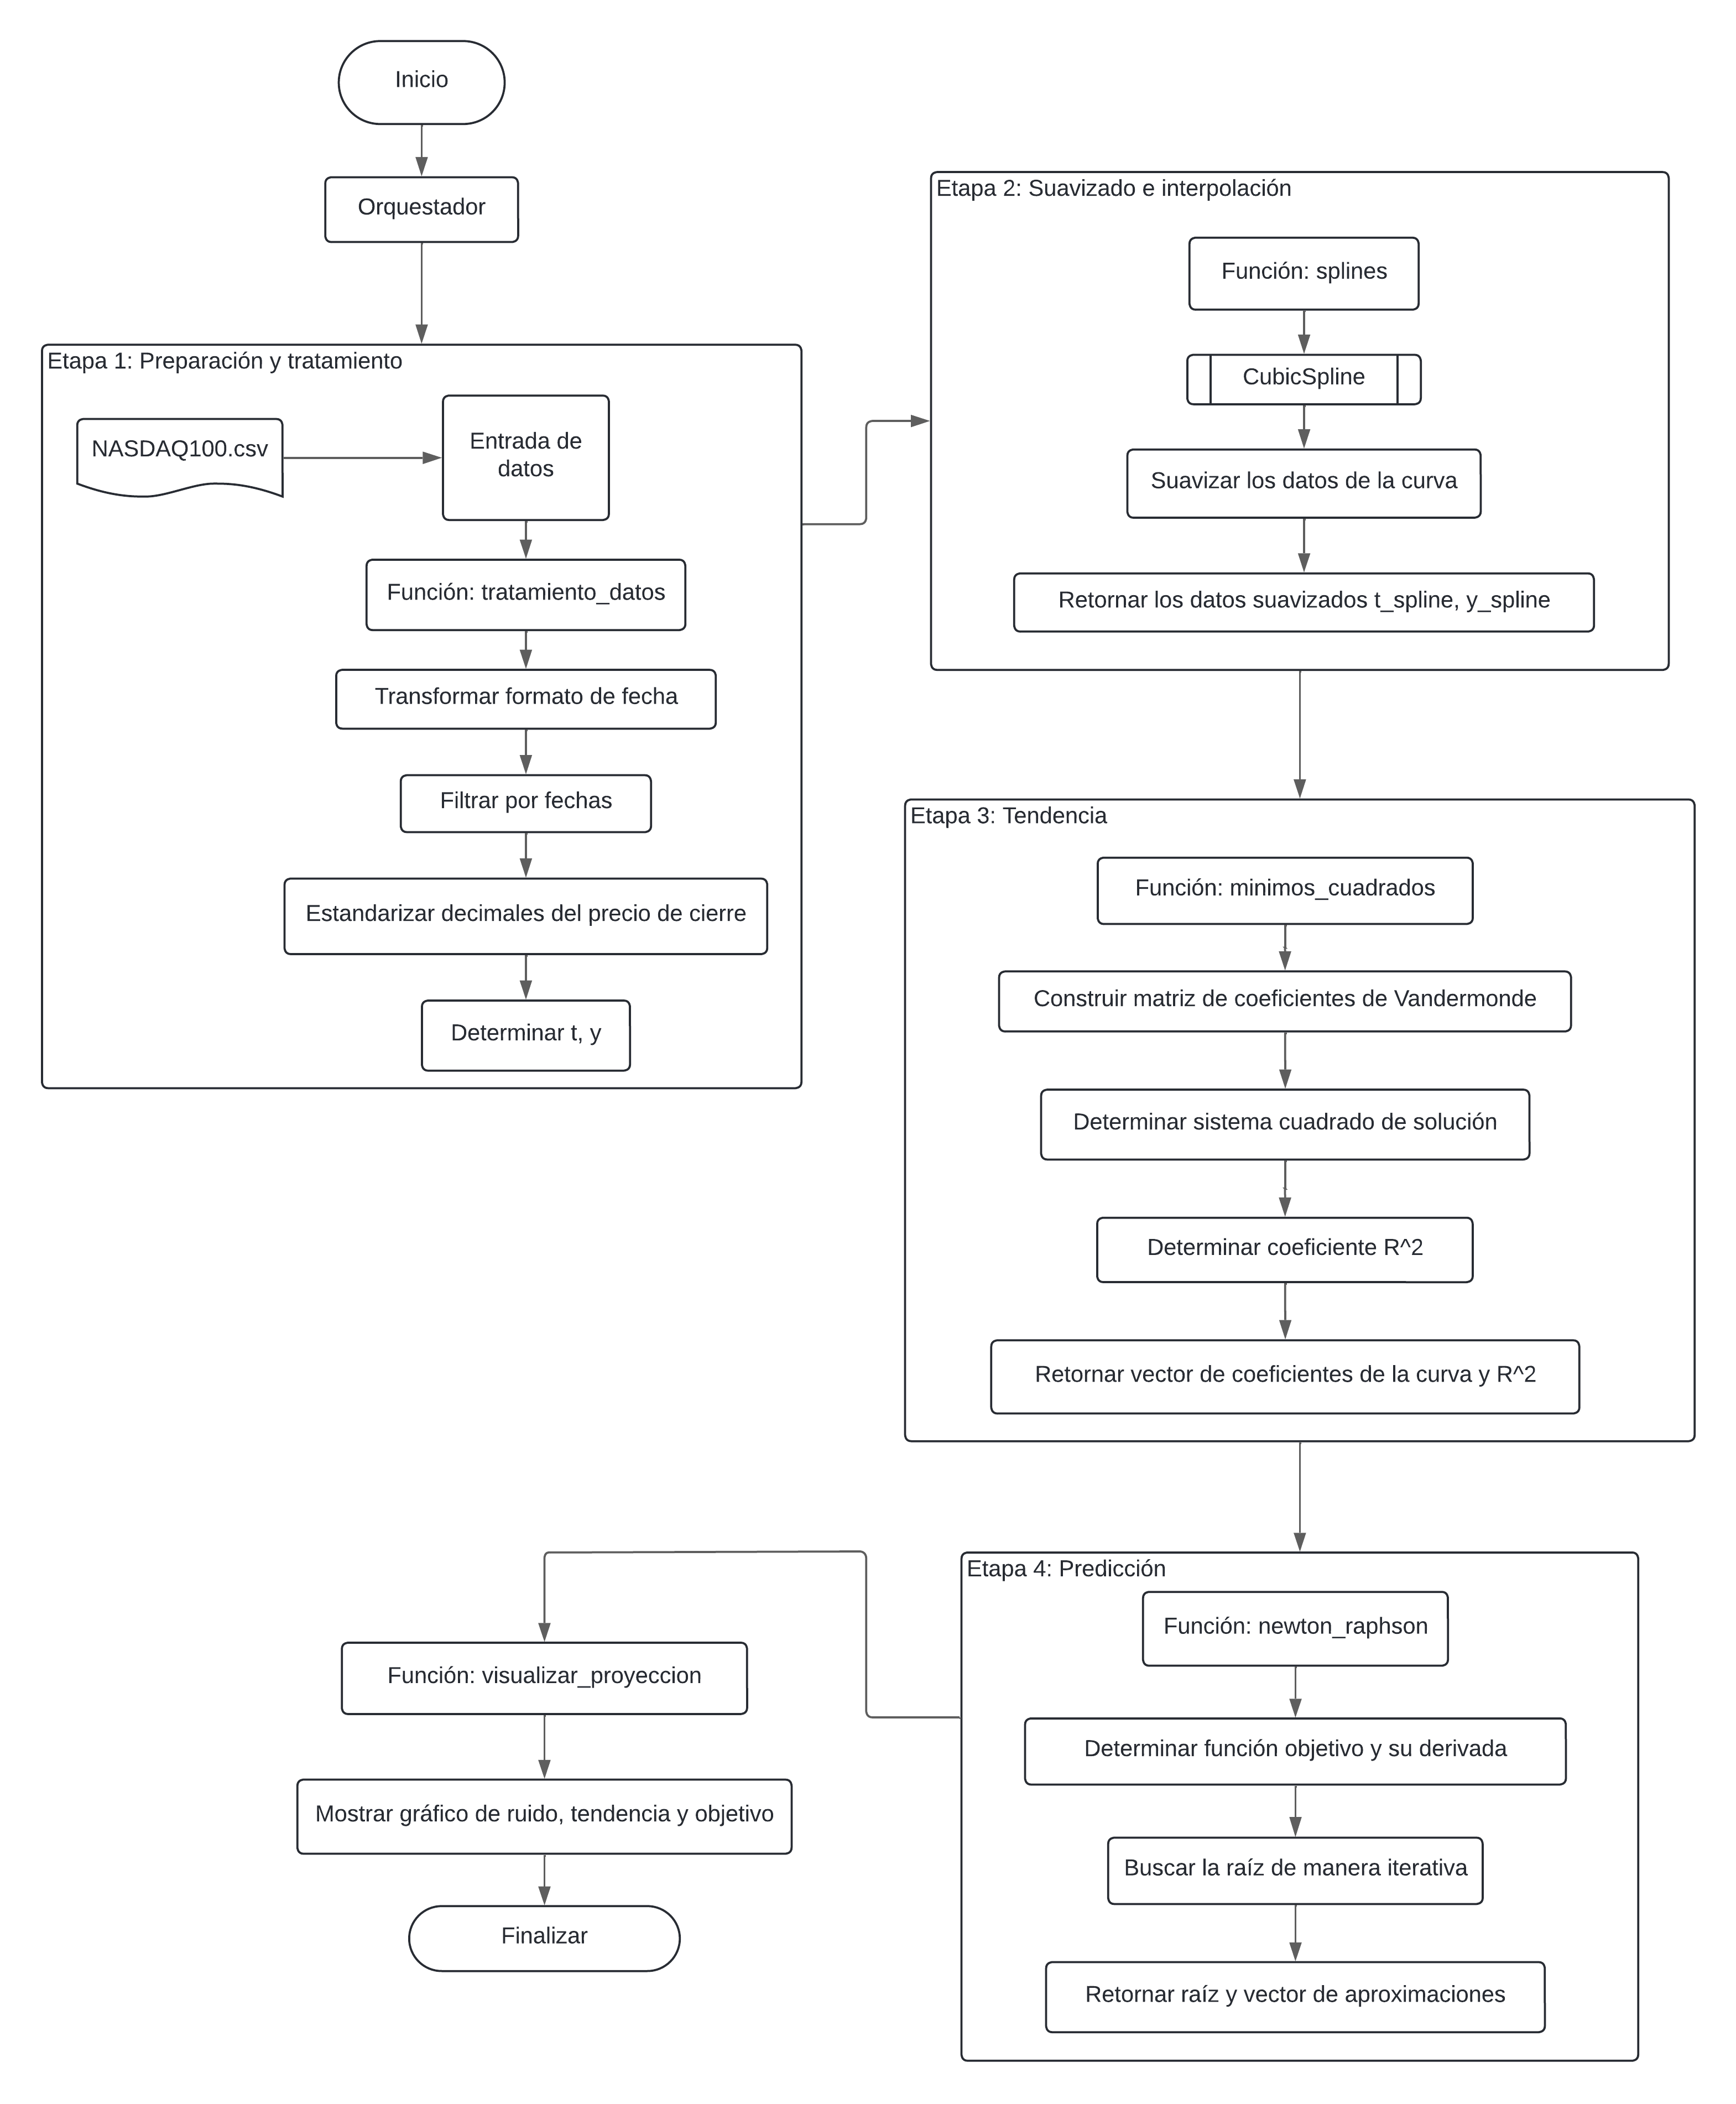

#TODO: https://pdfs.semanticscholar.org/4faa/15f05cdaa46c1bc1c000689f802d1cb607e0.pdf

Fuente para justificar el uso de hold - out, revisar el bucle para hallar el modelo de mejor ajuste, incluir función para graficar todas las predicciones. No incluir animación, o si? ----- 1 commit
Terminar de redactar mi parte del informe ***** 2 commit
Unir informe Erick ----- 3 commit